# 03 — Baseline: LogReg + TF-IDF

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

In [2]:
df_train = pd.read_csv("../data/processed/train.csv")
df_val   = pd.read_csv("../data/processed/val.csv")

X_train = df_train["text_clean"]
y_train = df_train["label"]
X_val   = df_val["text_clean"]
y_val   = df_val["label"]

print(f"Train: {len(df_train)}, Val: {len(df_val)}")

Train: 37104, Val: 6548


In [3]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)

print(f"Размер матрицы TF-IDF: {X_train_tfidf.shape}")

Размер матрицы TF-IDF: (37104, 50000)


In [4]:
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=SEED
)
lr.fit(X_train_tfidf, y_train)

y_pred = lr.predict(X_val_tfidf)

macro_f1 = f1_score(y_val, y_pred, average="macro")
print(f"Baseline Macro F1: {macro_f1:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=["negative", "neutral", "positive"]))

Baseline Macro F1: 0.7481

              precision    recall  f1-score   support

    negative       0.74      0.71      0.73      2224
     neutral       0.63      0.67      0.65      2173
    positive       0.88      0.85      0.87      2151

    accuracy                           0.75      6548
   macro avg       0.75      0.75      0.75      6548
weighted avg       0.75      0.75      0.75      6548



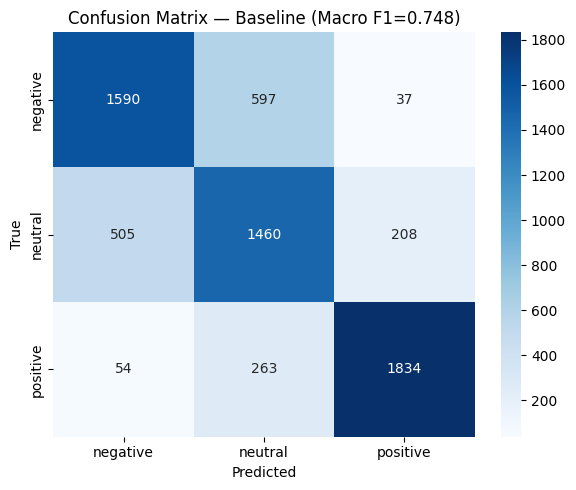

In [5]:
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)
plt.title(f"Confusion Matrix — Baseline (Macro F1={macro_f1:.3f})")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../data/processed/baseline_confusion_matrix.png", dpi=150)
plt.show()

In [6]:
results = pd.DataFrame([{
    "Model": "Baseline: LogReg + TF-IDF",
    "Macro F1": round(macro_f1, 4),
    "Note": "ngram (1,2), 50k features, C=1.0"
}])
results.to_csv("../data/processed/experiments_log.csv", index=False)
print(results.to_string(index=False))

                    Model  Macro F1                             Note
Baseline: LogReg + TF-IDF    0.7481 ngram (1,2), 50k features, C=1.0
